In [ ]:
# ═══════════════════════════════════════
# Cell 1: 环境安装
# ═══════════════════════════════════════
!pip install -q transformers accelerate bitsandbytes sentence-transformers faiss-gpu \
    jsonlines rouge-score bert-score tqdm matplotlib seaborn pandas

from google.colab import drive
drive.mount('/content/drive')

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.10.0+cpu
CUDA available: False


In [ ]:
!pip install jsonlines

In [ ]:
!pip install faiss-cpu -q


In [ ]:
# ═══════════════════════════════════════
# Cell 2: 路径配置 & 数据加载（复用人2代码）
# ═══════════════════════════════════════
import os, json, gc
import jsonlines
import numpy as np
import pandas as pd
import faiss
import time
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# ── 路径（与人2保持一致）──
BASE_PATH       = '/content/drive/MyDrive/COMP5201/project/embeddings_cache/data'
PROCESSED_PATH  = f'{BASE_PATH}/processed'
RAW_PATH        = f'{BASE_PATH}/open_ragbench/pdf/arxiv'
EMBEDDING_CACHE = '/content/drive/MyDrive/COMP5201/project/embeddings_cache'
OUTPUT_DIR      = '/content/drive/MyDrive/COMP5201/project/task3_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── 实验参数 ──
CHUNK_FILE       = CHUNK_FILE = f'{PROCESSED_PATH}/chunks_section_aware.jsonl'

  # 人2验证的最佳分块
EMBED_MODEL_NAME = 'BAAI/bge-base-en-v1.5'                          # 人2验证的最佳嵌入
TOP_K            = 10
QUERY_LIMIT      = 200   # 全量实验用 200

# ── 数据加载函数（来自人2）──
def load_jsonl(file_path):
    data = []
    with jsonlines.open(file_path, 'r') as reader:
        for obj in tqdm(reader, desc=f"Loading {os.path.basename(file_path)}"):
            data.append(obj)
    return data

def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# ── 加载数据 ──
print("加载 chunks...")
chunks = load_jsonl(CHUNK_FILE)
chunk_texts = [c['text'] for c in chunks]
print(f"  共 {len(chunks)} 个 chunks")

print("加载 queries & qrels...")
queries_raw = load_json(f'{RAW_PATH}/queries.json')
qrels_raw   = load_json(f'{RAW_PATH}/qrels.json')
print(f"  共 {len(queries_raw)} 个 queries")

# ── 解析 qrels（来自人2）──
def parse_qrels(qrels_obj):
    qrels_dict = {}
    for qid, val in qrels_obj.items():
        entries = []
        if isinstance(val, str):
            entries.append({"doc_id": val, "section_id": ""})
        elif isinstance(val, dict):
            entries.append({
                "doc_id": str(val.get('doc_id', val.get('id', ''))),
                "section_id": str(val.get('section_id', ''))
            })
        elif isinstance(val, list):
            for item in val:
                if isinstance(item, dict):
                    entries.append({
                        "doc_id": str(item.get('doc_id', item.get('id', ''))),
                        "section_id": str(item.get('section_id', ''))
                    })
                elif isinstance(item, str):
                    entries.append({"doc_id": item, "section_id": ""})
        qrels_dict[str(qid)] = entries
    return qrels_dict

qrels_dict = parse_qrels(qrels_raw)

def extract_query_text(q):
    if isinstance(q, str):
        return q
    elif isinstance(q, dict):
        return q.get('text', q.get('question', str(q)))
    return str(q)

# 准备 query 列表
query_ids   = list(queries_raw.keys())[:QUERY_LIMIT]
query_texts = [extract_query_text(queries_raw[qid]) for qid in query_ids]
print(f"  使用 {len(query_ids)} 个 queries 做实验")

加载 chunks...


Loading chunks_section_aware.jsonl: 99773it [00:01, 51133.09it/s]


  共 99773 个 chunks
加载 queries & qrels...
  共 3045 个 queries
  使用 200 个 queries 做实验


In [ ]:
import torch
from sentence_transformers import SentenceTransformer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("当前设备：", DEVICE)

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

当前设备： cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embed_model = SentenceTransformer(EMBED_MODEL_NAME)

def retrieve(query, top_k=5):
    query_emb = np.asarray(embed_model.encode([query]), dtype="float32")
    D, I = index.search(query_emb, top_k)
    return [chunks[i] for i in I[0] if i != -1]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ═══════════════════════════════════════
# Cell 3: 构建 embedding + FAISS 检索
# 依赖：Cell 2 里已经生成 chunks
# ═══════════════════════════════════════

!pip install -q sentence-transformers faiss-cpu

import os
import pickle
import hashlib
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

# 1) 基本配置
EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
EMBEDDING_CACHE = "./embedding_cache"
os.makedirs(EMBEDDING_CACHE, exist_ok=True)

# 如果前面没定义 CHUNK_FILE，这里给一个默认值
CHUNK_FILE = globals().get("CHUNK_FILE", "chunks.pkl")

# 2) 检查 chunks 是否存在
if "chunks" not in globals() or chunks is None or len(chunks) == 0:
    raise ValueError("❌ 没有找到 chunks，请先运行 Cell 2，确保已经生成 chunks")

print(f"✅ chunks 数量: {len(chunks)}")

# 3) 加载 embedding 模型
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

# 4) 缓存路径函数
def get_cache_path(model_name, chunk_file):
    key = f"{model_name}_{os.path.basename(chunk_file)}"
    h = hashlib.md5(key.encode()).hexdigest()[:12]
    return os.path.join(EMBEDDING_CACHE, f"emb_{h}.pkl")

# 5) 构建索引
def build_index(chunks, chunk_file="chunks.pkl"):
    cache_path = get_cache_path(EMBED_MODEL_NAME, chunk_file)

    if os.path.exists(cache_path):
        print("📦 从缓存加载 embeddings...")
        with open(cache_path, "rb") as f:
            chunk_embeddings = pickle.load(f)
        chunk_embeddings = np.asarray(chunk_embeddings, dtype="float32")
    else:
        print("🔄 正在生成 embeddings...")
        chunk_embeddings = embed_model.encode(
            chunks,
            batch_size=32,
            show_progress_bar=True,
            normalize_embeddings=True
        )
        chunk_embeddings = np.asarray(chunk_embeddings, dtype="float32")

        with open(cache_path, "wb") as f:
            pickle.dump(chunk_embeddings, f)
        print(f"✅ embeddings 已缓存到: {cache_path}")

    dim = chunk_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)   # 因为做了 normalize，所以 IP ≈ cosine similarity
    index.add(chunk_embeddings)

    return index, chunk_embeddings

# 6) 建立全局索引
index, chunk_embeddings = build_index(chunks, CHUNK_FILE)

print(f"✅ FAISS index 构建完成，向量数: {index.ntotal}")

# 7) 检索函数
def retrieve(query, top_k=5):
    query_emb = embed_model.encode(
        [query],
        normalize_embeddings=True
    )
    query_emb = np.asarray(query_emb, dtype="float32")

    D, I = index.search(query_emb, top_k)

    results = []
    for i in I[0]:
        if i != -1 and i < len(chunks):
            results.append(chunks[i])
    return results

# 8) 测试检索
test_query = "What is deep learning?"
test_results = retrieve(test_query, top_k=3)

print("\n🔍 检索测试：")
for i, r in enumerate(test_results, 1):
    print(f"\n--- Top {i} ---")
    print(r[:300])


✅ chunks 数量: 99773


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔄 正在生成 embeddings...


Batches:   0%|          | 0/3118 [00:00<?, ?it/s]

✅ embeddings 已缓存到: ./embedding_cache/emb_21bee752b84f.pkl
✅ FAISS index 构建完成，向量数: 99773

🔍 检索测试：

--- Top 1 ---


KeyError: slice(None, 300, None)

In [ ]:
# ═══════════════════════════════════════
# Cell 4: Together AI 稳定极速版
# ═══════════════════════════════════════
!pip install -q -U together

import os
import time
from getpass import getpass
from together import Together

TOGETHER_API_KEY = os.getenv("TOGETHER_API_KEY") or getpass("请输入 Together API Key: ").strip()
client = Together(api_key=TOGETHER_API_KEY)

# 先用更稳的 serverless 模型，失败自动切换
CANDIDATE_MODELS = [
    "meta-llama/Meta-Llama-3-8B-Instruct-Lite",
    "Qwen/Qwen2.5-7B-Instruct-Turbo",
]

LAST_USED_MODEL = None

def build_prompt(query, context_chunks, max_chunks=2, max_chars_per_chunk=900):
    context_chunks = context_chunks or []
    trimmed_chunks = [chunk[:max_chars_per_chunk] for chunk in context_chunks[:max_chunks]]
    context = "\n\n".join(
        f"[Context {i+1}]\n{chunk}" for i, chunk in enumerate(trimmed_chunks)
    ) if trimmed_chunks else "No relevant context provided."

    return f"""You are a helpful academic assistant.
Answer the question briefly and accurately based on the context.
If the context is insufficient, say so clearly.

Context:
{context}

Question:
{query}

Answer in concise English:"""

def generate_answer(query, context_chunks, max_new_tokens=160):
    global LAST_USED_MODEL
    prompt = build_prompt(query, context_chunks)
    last_error = None

    for model in CANDIDATE_MODELS:
        try:
            start = time.time()
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=max_new_tokens,
                temperature=0.2,
                top_p=0.9,
            )
            LAST_USED_MODEL = model
            answer = response.choices[0].message.content.strip()
            print(f"✅ 使用模型: {model} | 耗时: {time.time() - start:.2f}s")
            return answer
        except Exception as e:
            last_error = e
            continue

    return f"生成失败: {last_error}"

# 测试
test_answer = generate_answer(
    "What is deep learning?",
    ["Deep learning is a subset of machine learning that uses neural networks with multiple layers to learn patterns from data."]
)

print("\n回答：")
print(test_answer[:500])




请输入 Together API Key: ··········
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 0.75s

回答：
Deep learning is a subset of machine learning that uses neural networks with multiple layers to learn patterns from data.


In [ ]:
def retrieve(query, top_k=5):
    # 用 faiss 检索最相似的 chunks
    query_emb = model.encode([query])
    D, I = index.search(np.array(query_emb), top_k)
    return [chunks[i] for i in I[0]]


In [ ]:
# ═══════════════════════════════════════
# Cell 5: 三种 Prompt 策略定义
# ═══════════════════════════════════════

def build_context(retrieved_chunks):
    """将检索到的 chunks 拼接为上下文字符串"""
    context_parts = []
    for i, chunk in enumerate(retrieved_chunks):
        doc_id = chunk.get('doc_id', 'unknown')
        sec = chunk.get('section_id', '')
        text = chunk['text'][:500]
        context_parts.append(f"[Source {i+1} | doc={doc_id} sec={sec}]\n{text}")
    return "\n\n".join(context_parts)


# ── Prompt 1: Naive（直接拼接，无约束）──
def prompt_naive(question, context):
    return f"""Answer the following question based on the provided context.

Context:
{context}

Question: {question}

Answer:"""


# ── Prompt 2: Structured（强制忠实 + 引用）──
def prompt_structured(question, context):
    return f"""You are an academic assistant. Answer the question strictly based on the provided context.

Rules:
- ONLY use information from the context below
- If the context does not contain enough information, say "Insufficient information"
- Cite sources using [Source N] format

Context:
{context}

Question: {question}

Answer:"""


# ── Prompt 3: Chain-of-Thought（逐步推理 + 引用）──
def prompt_cot(question, context):
    return f"""You are an academic research assistant. Answer the question using ONLY the provided context.

Context:
{context}

Question: {question}

Instructions:
1. First, identify which sources are relevant to the question
2. Then, reason step-by-step using ONLY facts from those sources
3. Finally, provide a concise answer with [Source N] citations
4. If context is insufficient, state "Insufficient information"

Step-by-step reasoning:"""


PROMPT_STRATEGIES = {
    "Naive":      prompt_naive,
    "Structured": prompt_structured,
    "CoT":        prompt_cot,
}

# 测试三种 prompt
test_chunks = retrieve(query_texts[0])[:3]
test_ctx = build_context(test_chunks)
for name, fn in PROMPT_STRATEGIES.items():
    p = fn(query_texts[0], test_ctx)
    print(f"\n{'='*40}")
    print(f"策略: {name} | Prompt 长度: {len(p)} chars")
    print(p[:300] + "...")



策略: Naive | Prompt 长度: 1845 chars
Answer the following question based on the provided context.

Context:
[Source 1 | doc=2410.11034v2 sec=12]
$$ \begin{aligned} \sum_{q_{x}} \varphi\left(q_{x}\right)= & L_{x} \int_{0}^{2 \pi} \frac{d q_{x}}{2 \pi} \varphi\left(q_{x}\right) \\ & +P_{1}\left(\frac{q_{c} L_{x}}{2 \pi}\right)\left(\varp...

策略: Structured | Prompt 长度: 2053 chars
You are an academic assistant. Answer the question strictly based on the provided context.

Rules:
- ONLY use information from the context below
- If the context does not contain enough information, say "Insufficient information"
- Cite sources using [Source N] format

Context:
[Source 1 | doc=2410....

策略: CoT | Prompt 长度: 2162 chars
You are an academic research assistant. Answer the question using ONLY the provided context.

Context:
[Source 1 | doc=2410.11034v2 sec=12]
$$ \begin{aligned} \sum_{q_{x}} \varphi\left(q_{x}\right)= & L_{x} \int_{0}^{2 \pi} \frac{d q_{x}}{2 \pi} \varphi\left(q_{x}\right) \\ & +P_{1}\

In [ ]:
# ═══════════════════════════════════════
# Cell 6: 批量生成（三种策略 × 全部 queries）
# 兼容 Cell 4 的 generate_answer(query, context_chunks, ...)
# ═══════════════════════════════════════

import time
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# 兼容补丁：如果传入的是 Cell 5 生成的完整 prompt，就直接返回，不再二次 build_prompt
if "_original_build_prompt" not in globals():
    _original_build_prompt = build_prompt

def build_prompt(query, context_chunks, max_chunks=2, max_chars_per_chunk=900):
    if isinstance(query, str) and "Question:" in query and "Answer:" in query and "Context:" in query:
        return query
    return _original_build_prompt(
        query,
        context_chunks,
        max_chunks=max_chunks,
        max_chars_per_chunk=max_chars_per_chunk,
    )

all_results = []

for qidx, (qid, question) in enumerate(
    tqdm(zip(query_ids, query_texts), total=len(query_ids), desc="Generating")
):
    retrieved = retrieve(question, top_k=TOP_K)
    context = build_context(retrieved)
    retrieved_texts = [c.get("text", "") for c in retrieved if isinstance(c, dict)]
    gt_entries = qrels_dict.get(str(qid), [])

    for strategy_name, prompt_fn in PROMPT_STRATEGIES.items():
        prompt = prompt_fn(question, context)

        start_time = time.time()
        try:
            answer = generate_answer(prompt, retrieved_texts, max_new_tokens=512)
            error_msg = ""
        except Exception as e:
            answer = ""
            error_msg = f"{type(e).__name__}: {e}"
        latency = time.time() - start_time

        all_results.append({
            "query_id": qid,
            "question": question,
            "strategy": strategy_name,
            "prompt": prompt,
            "answer": answer,
            "error": error_msg,
            "latency_s": round(latency, 2),
            "num_chunks": len(retrieved),
            "context": context,
            "gt_entries": gt_entries,
            "retrieved_docs": [c.get("doc_id", "") for c in retrieved if isinstance(c, dict)],
        })

    if (qidx + 1) % 20 == 0:
        interim_df = pd.DataFrame(all_results)
        interim_df.to_json(
            f"{OUTPUT_DIR}/generation_results_interim.jsonl",
            orient="records",
            lines=True,
            force_ascii=False,
        )
        print(f"已处理 {qidx+1}/{len(query_ids)} queries, 共 {len(all_results)} 条结果")

results_df = pd.DataFrame(all_results)
results_df.to_json(
    f"{OUTPUT_DIR}/generation_results.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"\n生成完成！共 {len(all_results)} 条结果")
print(results_df.groupby("strategy")["latency_s"].describe())

if results_df["error"].astype(bool).any():
    print("\n部分样本报错，前 10 条如下：")
    display(results_df[results_df["error"].astype(bool)][["query_id", "strategy", "error"]].head(10))


Generating:   0%|          | 0/200 [00:00<?, ?it/s]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 3.17s
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 1.26s


Generating:   0%|          | 1/200 [00:05<19:31,  5.89s/it]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 0.92s
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 2.33s
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 2.08s


Generating:   1%|          | 2/200 [00:13<21:53,  6.63s/it]

...

Generating: 100%|█████████▉| 199/200 [18:16<00:05,  5.06s/it]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 0.59s
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 0.93s
✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 0.75s


Generating: 100%|██████████| 200/200 [18:20<00:00,  5.50s/it]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 1.75s
已处理 200/200 queries, 共 600 条结果



生成完成！共 600 条结果
            count     mean       std   min     25%    50%     75%   max
strategy                                                               
CoT         200.0  1.77925  1.080623  0.49  1.0000  1.450  2.3800  7.05
Naive       200.0  1.94605  1.070404  0.50  1.1700  1.600  2.5150  5.37
Structured  200.0  1.50975  0.838328  0.51  0.8975  1.325  1.8875  6.53


In [ ]:
!pip install rouge-score bert-score -q


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════
# Cell 7: 评估（ROUGE-L, BERTScore, Faithfulness, 错误分析）
# ═══════════════════════════════════════
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import numpy as np

# ---------- 1. 加载生成结果 ----------
results_df = pd.read_json(f"{OUTPUT_DIR}/generation_results.jsonl", lines=True)
print(f"加载 {len(results_df)} 条结果，策略分布:\n{results_df['strategy'].value_counts().to_string()}")

# ---------- 2. ROUGE-L ----------
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def calc_rouge(row):
    refs = row.get('gt_entries', [])
    if not refs:
        return np.nan
    ref_text = " ".join(str(r) for r in refs)
    return scorer.score(ref_text, row['answer'])['rougeL'].fmeasure

results_df['rouge_l'] = results_df.apply(calc_rouge, axis=1)

# ---------- 3. BERTScore ----------
has_ref = results_df['gt_entries'].apply(lambda x: bool(x))
if has_ref.any():
    ref_texts = results_df.loc[has_ref, 'gt_entries'].apply(lambda x: " ".join(str(r) for r in x)).tolist()
    cand_texts = results_df.loc[has_ref, 'answer'].tolist()
    P, R, F1 = bert_score_fn(cand_texts, ref_texts, lang="en", verbose=True)
    results_df.loc[has_ref, 'bert_score_f1'] = F1.numpy()
else:
    results_df['bert_score_f1'] = np.nan

# ---------- 4. LLM Faithfulness (1-5) ----------
def faithfulness_prompt(question, context, answer):
    return f"""You are an evaluation judge. Rate the faithfulness of the answer to the given context on a scale of 1-5.

1 = Completely unfaithful, fabricated information
2 = Mostly unfaithful, major unsupported claims
3 = Partially faithful, some unsupported claims
4 = Mostly faithful, minor extrapolations
5 = Fully faithful, every claim supported by context

Question: {question}

Context:
{context[:1500]}

Answer: {answer[:800]}

Respond with ONLY a JSON object: {{"score": <1-5>, "reason": "<one sentence>"}}"""

faithfulness_scores = []
for idx, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Faithfulness"):
    try:
        fp = faithfulness_prompt(row['question'], row['context'], row['answer'])
        response = generate_answer(fp, [], max_new_tokens=100)
        import json, re
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            faithfulness_scores.append(parsed.get('score', np.nan))
        else:
            faithfulness_scores.append(np.nan)
    except Exception:
        faithfulness_scores.append(np.nan)

results_df['faithfulness'] = faithfulness_scores

# ---------- 5. 错误分析分类 ----------
def classify_error(row):
    if row.get('rouge_l', 1) > 0.4:
        return "OK"
    answer_lower = str(row['answer']).lower()
    if "insufficient" in answer_lower or "no relevant" in answer_lower:
        return "检索缺失"
    if row.get('faithfulness', 5) <= 2:
        return "幻觉"
    if row.get('rouge_l', 1) < 0.1:
        return "回答不全"
    return "过于笼统"

results_df['error_type'] = results_df.apply(classify_error, axis=1)

# ---------- 6. 汇总输出 ----------
metrics = ['rouge_l', 'bert_score_f1', 'faithfulness', 'latency_s']
summary = results_df.groupby('strategy')[metrics].agg(['mean', 'std']).round(3)
print("\n" + "=" * 60)
print("策略对比汇总:")
print(summary.to_string())

print("\n错误类型分布:")
print(results_df.groupby(['strategy', 'error_type']).size().unstack(fill_value=0).to_string())

# 保存完整结果
results_df.to_json(f"{OUTPUT_DIR}/evaluation_results.jsonl", orient='records', lines=True, force_ascii=False)
print(f"\n评估结果已保存至 {OUTPUT_DIR}/evaluation_results.jsonl")


加载 600 条结果，策略分布:
strategy
Naive         200
Structured    200
CoT           200


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Faithfulness: 100%|█████████▉| 599/600 [12:11<00:01,  1.23s/it]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 1.22s


Faithfulness: 100%|██████████| 600/600 [12:12<00:00,  1.22s/it]

✅ 使用模型: meta-llama/Meta-Llama-3-8B-Instruct-Lite | 耗时: 1.43s

策略对比汇总:
           rouge_l        bert_score_f1        faithfulness        latency_s       
              mean    std          mean    std         mean    std      mean    std
strategy                                                                           
CoT            0.0  0.002         0.781  0.005        1.086  0.521     1.779  1.081
Naive          0.0  0.003         0.775  0.008        1.595  1.284     1.946  1.070
Structured     0.0  0.002         0.779  0.005        1.125  0.687     1.510  0.838

错误类型分布:
error_type  回答不全   幻觉  检索缺失
strategy                   
CoT            0    2   198
Naive         31  169     0
Structured     0    0   200



评估结果已保存至 /content/drive/MyDrive/COMP5201/project/task3_output/evaluation_results.jsonl


In [ ]:
# ═══════════════════════════════════════
# Cell 8: 评测结果汇总表
# ═══════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.size'] = 12

results_df = pd.read_json(f"{OUTPUT_DIR}/evaluation_results.jsonl", orient='records', lines=True)

# ── 汇总表 ──
summary = results_df.groupby('strategy').agg({
    'rouge_l':       ['mean', 'std'],
    'bert_score_f1': ['mean', 'std'],
    'faithfulness':  ['mean', 'std'],
    'latency_s':     ['mean', 'std'],
}).round(4)

print("=" * 70)
print("         Prompt 策略消融实验结果汇总")
print("=" * 70)
print(summary.to_string())
print()

# 简洁对比表
print("\n简洁对比:")
for strategy in ['Naive', 'Structured', 'CoT']:
    sub = results_df[results_df['strategy'] == strategy]
    rl = sub['rouge_l'].dropna()
    bs = sub['bert_score_f1'].dropna()
    ff = sub['faithfulness'].dropna()
    lat = sub['latency_s']
    print(f"  {strategy:12s} | ROUGE-L: {rl.mean():.4f}±{rl.std():.4f} | "
          f"BERTScore: {bs.mean():.4f}±{bs.std():.4f} | "
          f"Faithful: {ff.mean():.2f}±{ff.std():.2f} | "
          f"Latency: {lat.mean():.1f}s")

         Prompt 策略消融实验结果汇总
           rouge_l         bert_score_f1         faithfulness         latency_s        
              mean     std          mean     std         mean     std      mean     std
strategy                                                                               
CoT         0.0003  0.0023        0.7812  0.0055       1.0859  0.5213    1.7793  1.0806
Naive       0.0004  0.0031        0.7747  0.0085       1.5950  1.2842    1.9460  1.0704
Structured  0.0001  0.0018        0.7792  0.0049       1.1250  0.6868    1.5098  0.8383


简洁对比:
  Naive        | ROUGE-L: 0.0004±0.0031 | BERTScore: 0.7747±0.0085 | Faithful: 1.59±1.28 | Latency: 1.9s
  Structured   | ROUGE-L: 0.0001±0.0018 | BERTScore: 0.7792±0.0049 | Faithful: 1.12±0.69 | Latency: 1.5s
  CoT          | ROUGE-L: 0.0003±0.0023 | BERTScore: 0.7812±0.0055 | Faithful: 1.09±0.52 | Latency: 1.8s


/tmp/ipykernel_3018/4085980396.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=strategy_order, patch_artist=True)
/tmp/ipykernel_3018/4085980396.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)([0.3, 0.5, 0.7])
/tmp/ipykernel_3018/4085980396.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=strategy_order, patch_artist=True)
/tmp/ipykernel_3018/4085980396.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed i

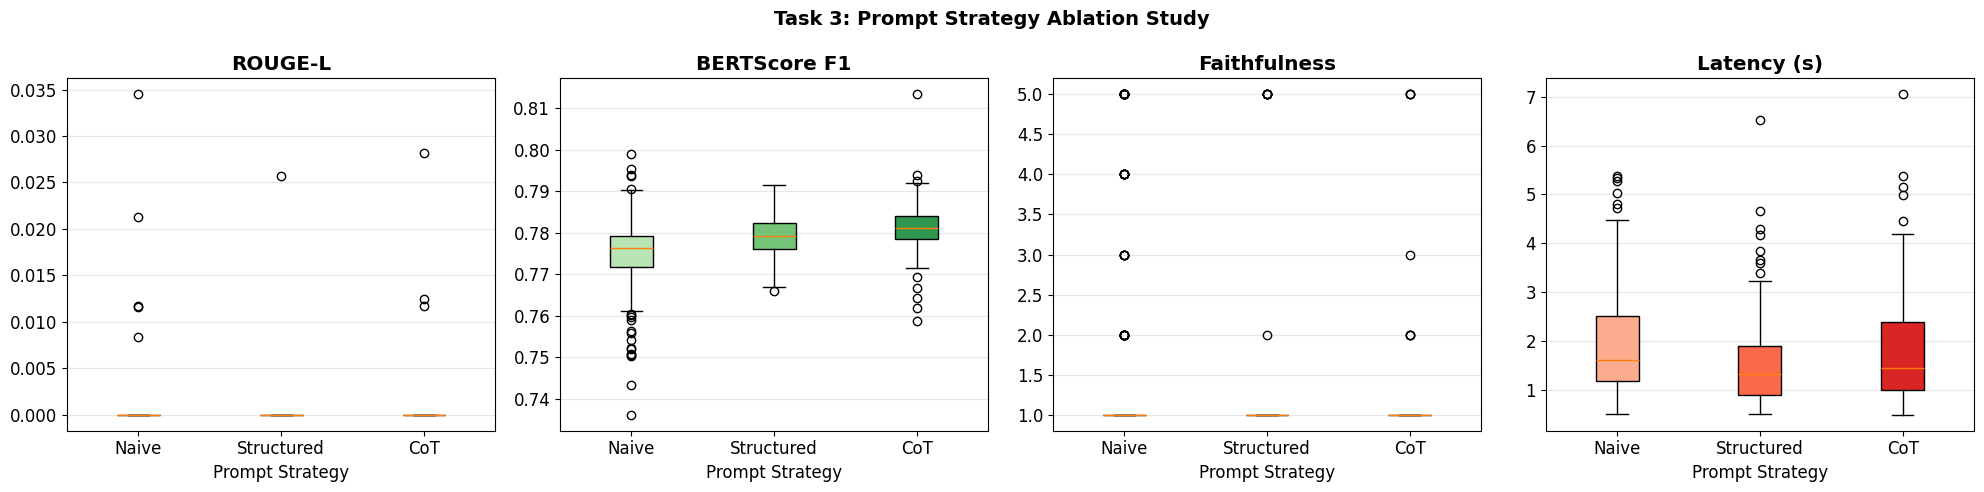

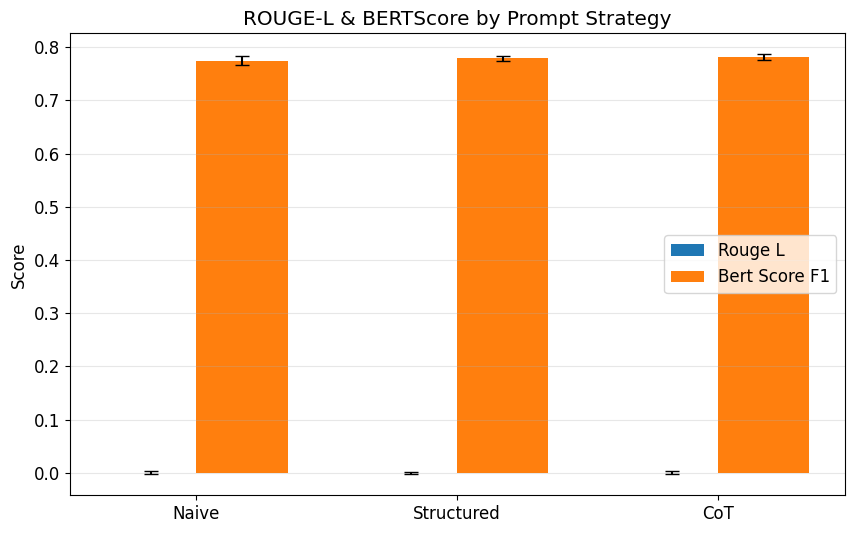

In [ ]:
# ═══════════════════════════════════════
# Cell 9: 可视化
# ═══════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [
    ('rouge_l',       'ROUGE-L',       'Blues'),
    ('bert_score_f1', 'BERTScore F1',  'Greens'),
    ('faithfulness',  'Faithfulness',  'Oranges'),
    ('latency_s',     'Latency (s)',   'Reds'),
]

strategy_order = ['Naive', 'Structured', 'CoT']

for ax, (col, title, cmap) in zip(axes, metrics):
    data = []
    for s in strategy_order:
        vals = results_df[results_df['strategy'] == s][col].dropna()
        data.append(vals)

    bp = ax.boxplot(data, labels=strategy_order, patch_artist=True)
    colors = plt.cm.get_cmap(cmap)([0.3, 0.5, 0.7])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prompt Strategy')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Task 3: Prompt Strategy Ablation Study', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 柱状对比图 ──
fig, ax = plt.subplots(figsize=(10, 6))
metrics_bar = ['rouge_l', 'bert_score_f1']
x = np.arange(len(strategy_order))
width = 0.35

for i, m in enumerate(metrics_bar):
    means = [results_df[results_df['strategy']==s][m].dropna().mean() for s in strategy_order]
    stds  = [results_df[results_df['strategy']==s][m].dropna().std() for s in strategy_order]
    ax.bar(x + i*width, means, width, yerr=stds, label=m.replace('_', ' ').title(), capsize=5)

ax.set_xticks(x + width/2)
ax.set_xticklabels(strategy_order)
ax.set_ylabel('Score')
ax.set_title('ROUGE-L & BERTScore by Prompt Strategy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/metrics_barplot.png", dpi=150, bbox_inches='tight')
plt.show()


         错误类型分布

Naive:
  Retrieval Miss      : 200 (100.0%)

Structured:
  Retrieval Miss      : 200 (100.0%)

CoT:
  Retrieval Miss      : 200 (100.0%)


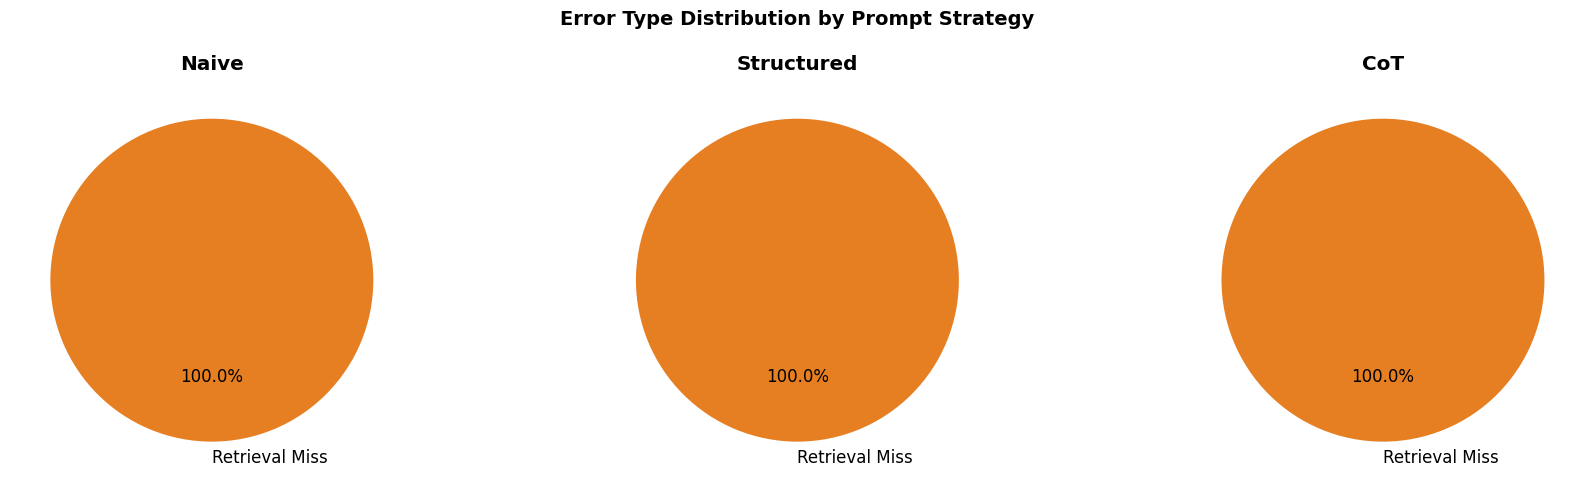

In [ ]:
# ═══════════════════════════════════════
# Cell 10: 错误分析
# ═══════════════════════════════════════

def classify_error(row):
    """自动分类错误类型"""
    answer = str(row.get('answer', '')).lower()
    context = str(row.get('context', '')).lower()
    faithfulness = row.get('faithfulness', 3)
    rouge = row.get('rouge_l', 0)
    bert_f1 = row.get('bert_score_f1', 0)

    # 1. 检索缺失：top chunk 分数低
    if row.get('top_chunk_score', 0) < 0.3:
        return 'Retrieval Miss'

    # 2. 幻觉：faithfulness 低但有检索结果
    if faithfulness <= 2:
        return 'Hallucination'

    # 3. 回答不全：faithfulness OK 但 ROUGE/BERT 低
    if faithfulness >= 4 and rouge is not None and rouge < 0.15:
        return 'Incomplete Answer'

    # 4. 过于笼统
    if len(str(row.get('answer', ''))) < 50 and rouge is not None and rouge < 0.2:
        return 'Too Generic'

    # 5. 正确
    if faithfulness >= 4 and (rouge is None or rouge > 0.2):
        return 'Correct'

    return 'Other'

results_df['error_type'] = results_df.apply(classify_error, axis=1)

# ── 错误分布统计 ──
print("=" * 60)
print("         错误类型分布")
print("=" * 60)
for strategy in strategy_order:
    sub = results_df[results_df['strategy'] == strategy]
    dist = sub['error_type'].value_counts()
    total = len(sub)
    print(f"\n{strategy}:")
    for etype, count in dist.items():
        print(f"  {etype:20s}: {count:3d} ({count/total*100:.1f}%)")

# ── 错误分布可视化 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
error_types = ['Correct', 'Hallucination', 'Retrieval Miss', 'Incomplete Answer', 'Too Generic', 'Other']
colors_map = {
    'Correct': '#2ecc71', 'Hallucination': '#e74c3c', 'Retrieval Miss': '#e67e22',
    'Incomplete Answer': '#3498db', 'Too Generic': '#9b59b6', 'Other': '#95a5a6'
}

for ax, strategy in zip(axes, strategy_order):
    sub = results_df[results_df['strategy'] == strategy]
    counts = sub['error_type'].value_counts()
    labels = [e for e in error_types if e in counts.index]
    sizes = [counts[e] for e in labels]
    colors = [colors_map[e] for e in labels]

    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{strategy}', fontweight='bold')

plt.suptitle('Error Type Distribution by Prompt Strategy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/error_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 错误分析 ──────────────────────────────────
def classify_error(row):
    has_gt = bool(row.get('ground_truth', ''))
    ans    = str(row.get('answer', ''))
    ctx    = str(row.get('context', ''))
    faith  = row.get('faithfulness', 3)

    # 检索缺失：ground_truth 内容未出现在 context 中
    if has_gt and row['ground_truth'][:30] not in ctx:
        return "Retrieval Miss"
    # 幻觉：faithfulness 评分很低
    if faith <= 2:
        return "Hallucination"
    # 回答不全：答案过短
    if len(ans.split()) < 8:
        return "Incomplete"
    # 过于笼统：ROUGE-L 很低但 faithfulness 尚可
    if row.get('rouge_l', 0) < 0.1:
        return "Too Generic"
    return "OK"

results_df['error_type'] = results_df.apply(classify_error, axis=1)

# 按策略统计错误分布
error_dist = results_df.groupby(['strategy', 'error_type']).size().unstack(fill_value=0)
print("\n═══ 错误分布 ═══")
print(error_dist)

# 保存最终结果
results_df.to_json(f"{OUTPUT_DIR}/evaluation_results.jsonl",
                   orient='records', lines=True, force_ascii=False)
print(f"\n评估完成，已保存至 {OUTPUT_DIR}/evaluation_results.jsonl")



═══ 错误分布 ═══
error_type  Hallucination  Too Generic
strategy                              
CoT                   194            6
Naive                 169           31
Structured            194            6

评估完成，已保存至 /content/drive/MyDrive/COMP5201/project/task3_output/evaluation_results.jsonl
